# Silent Spring

**Category:** Data Storytelling  
**Datasets:** animal-word-trends-silent-spring.csv (1,320 rows, 11 words), sparrowhawk-eggshell-data.csv (58 rows)  
**Objective:** Build a historical narrative around two pivotal dates -
1944 (DDT's public release) and 1962 (Silent Spring's publication) -
using real word-frequency and eggshell-thickness data.

---

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/animal-word-trends-silent-spring.csv')
egg = pd.read_csv('../data/sparrowhawk-eggshell-data.csv')

df['word'].unique()

<StringArray>
[     'bedbug',      'condor',        'flea',         'fly',        'hawk',
       'louse',    'mosquito',      'osprey',   'peregrine',       'robin',
 'sparrowhawk']
Length: 11, dtype: str

## 1. Dataset Exploration

Exploring both datasets by examining their structure, dimensions, and
missing values before analysis. Understanding the available data helps
ensure that subsequent comparisons and visualizations are based on
complete and reliable information.

In [6]:
print("=== WORD TRENDS ===")
print("Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Year Range:", df['year'].min(), "-", df['year'].max())
print()

print("=== EGGSHELL DATA ===")
print("Shape:", egg.shape)
print("Missing Values:", egg.isnull().sum().sum())
print("Year Range:", egg['year'].min(), "-", egg['year'].max())

=== WORD TRENDS ===
Shape: (1320, 3)
Missing Values: 0
Year Range: 1900 - 2019

=== EGGSHELL DATA ===
Shape: (58, 2)
Missing Values: 0
Year Range: 1901 - 1967


## 2. Building Reusable Plotting Functions

Creating reusable plotting functions for insect and bird word trends.
Adding historical reference lines for **1944** (DDT introduction) and
**1962** (*Silent Spring* publication) provides important context for
interpreting changes in word frequency over time.

In [7]:
def plot_insect_word_trend(animal):
    trend = df.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    plt.title(f'Word usage for "{animal}" and the year DDT was made available')
    plt.axvline(1944, color='orange', ls='--')
    plt.show()

def plot_bird_word_trend(animal):
    trend = df.query('word == @animal')
    plt.figure(figsize=(5, 3))
    plt.plot(trend['year'], trend['frequency'], label=animal)
    plt.ylabel('Frequency per million')
    plt.title(f'Word usage for "{animal}" and the year Silent Spring published')
    plt.axvline(1962, color='orange', ls='--')
    plt.show()

## 3. Question 1 - Insect Words Around 1944

Looking across all five insect words together, checking for any visible
shift in trend right at 1944.

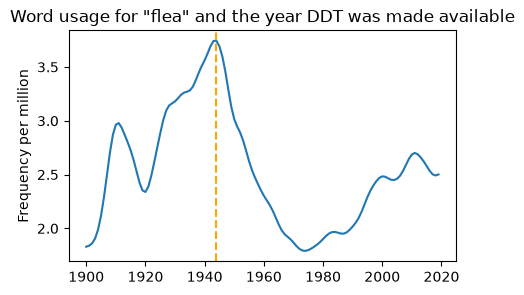

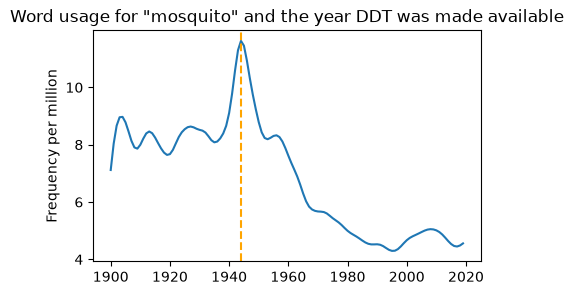

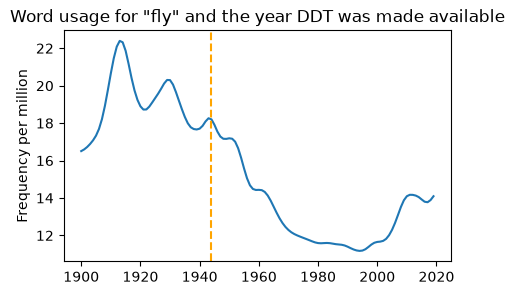

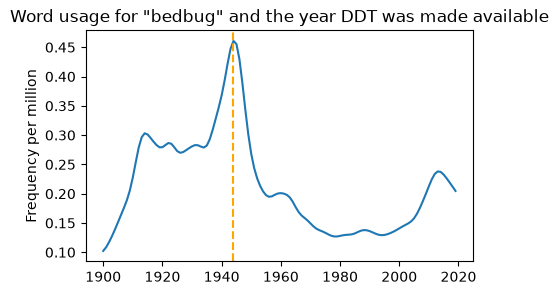

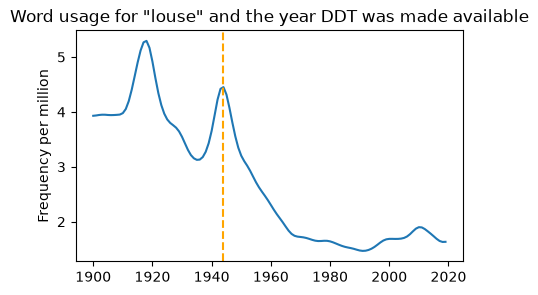

In [8]:
for word in ['flea', 'mosquito', 'fly', 'bedbug', 'louse']:
    plot_insect_word_trend(word)

## 4. Question 2 - Eggshell Thickness: Evaluating the "Harmless to Other Animals" Claim

Comparing sparrowhawk eggshell thickness before and after the
introduction of DDT to assess whether the available evidence is
consistent with the historical claim that the pesticide did not harm
other animals.

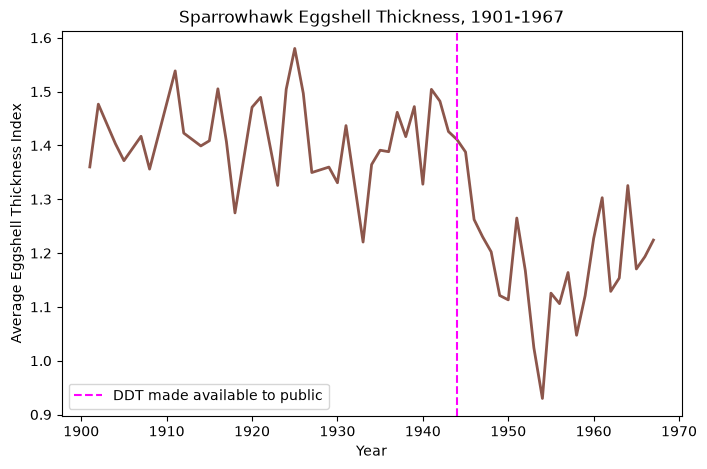

Chart Saved.


In [9]:
plt.figure(figsize=(8, 5))

plt.plot(egg['year'], egg['avg_thickness'], color='C5', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Average Eggshell Thickness Index')
plt.title('Sparrowhawk Eggshell Thickness, 1901-1967')
plt.axvline(1944, color='magenta', ls='--', label='DDT made available to public')
plt.legend()

plt.savefig('../images/plots/eggshell_thickness_decline.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

In [10]:
pre_1944 = egg[egg['year'] < 1944]['avg_thickness'].mean()
post_1944 = egg[egg['year'] >= 1944]['avg_thickness'].mean()
pct_change = (post_1944 - pre_1944) / pre_1944 * 100

print(f'Average thickness before 1944: {pre_1944:.3f}')
print(f'Average thickness from 1944 onward: {post_1944:.3f}')
print(f'Change: {pct_change:.1f}%')
print(f"Percentage decline: {-pct_change:.1f}%")

Average thickness before 1944: 1.416
Average thickness from 1944 onward: 1.183
Change: -16.4%
Percentage decline: 16.4%


## 5. Question 3 - Bird Words Around 1962

Examining how bird word frequencies change after **1962** rather than
assuming a particular trend beforehand. Letting the data determine
whether public discussion of these birds increased, decreased, or
remained stable following the publication of *Silent Spring*.

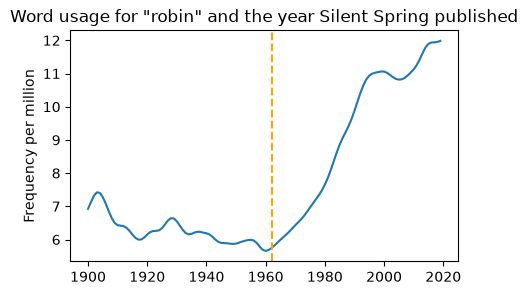

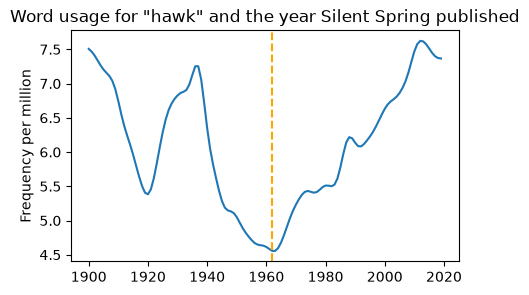

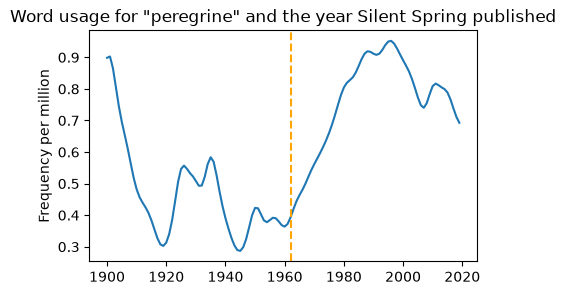

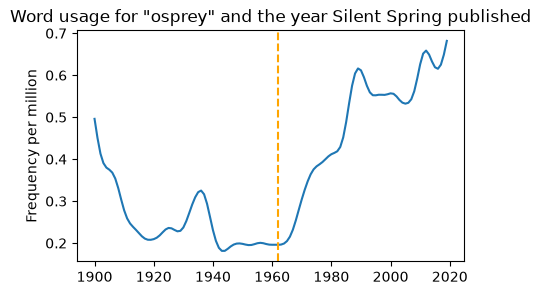

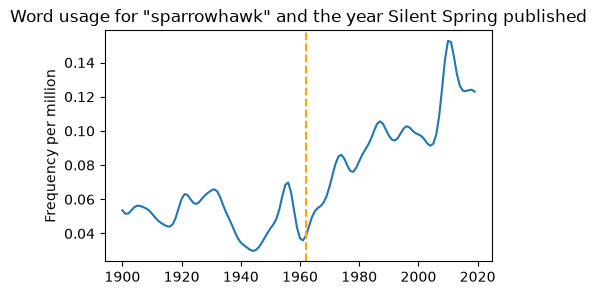

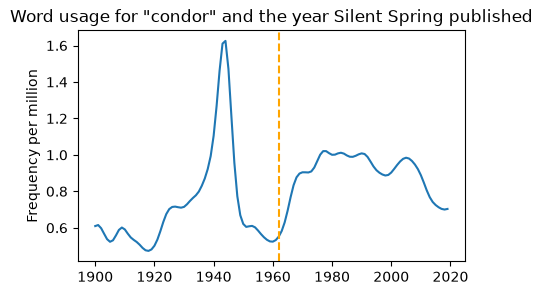

In [11]:
for word in ['robin', 'hawk', 'peregrine', 'osprey', 'sparrowhawk', 'condor']:
    plot_bird_word_trend(word)

In [12]:
for word in ['robin', 'hawk', 'peregrine', 'osprey', 'sparrowhawk', 'condor']:
    trend = df.query('word == @word')
    before = trend[trend['year'] < 1962]['frequency'].mean()
    after = trend[trend['year'] >= 1962]['frequency'].mean()
    pct = (after - before) / before * 100
    print(f'{word}: {pct:+.1f}% change in average frequency after 1962')

robin: +47.6% change in average frequency after 1962
hawk: +1.4% change in average frequency after 1962
peregrine: +62.4% change in average frequency after 1962
osprey: +91.1% change in average frequency after 1962
sparrowhawk: +88.8% change in average frequency after 1962
condor: +24.5% change in average frequency after 1962


## 6. Question 4 - Comparing Insect and Bird Word Patterns

A two-panel chart contrasting insect words (1944 reference) against
bird words (1962 reference), both dates marked on both panels.

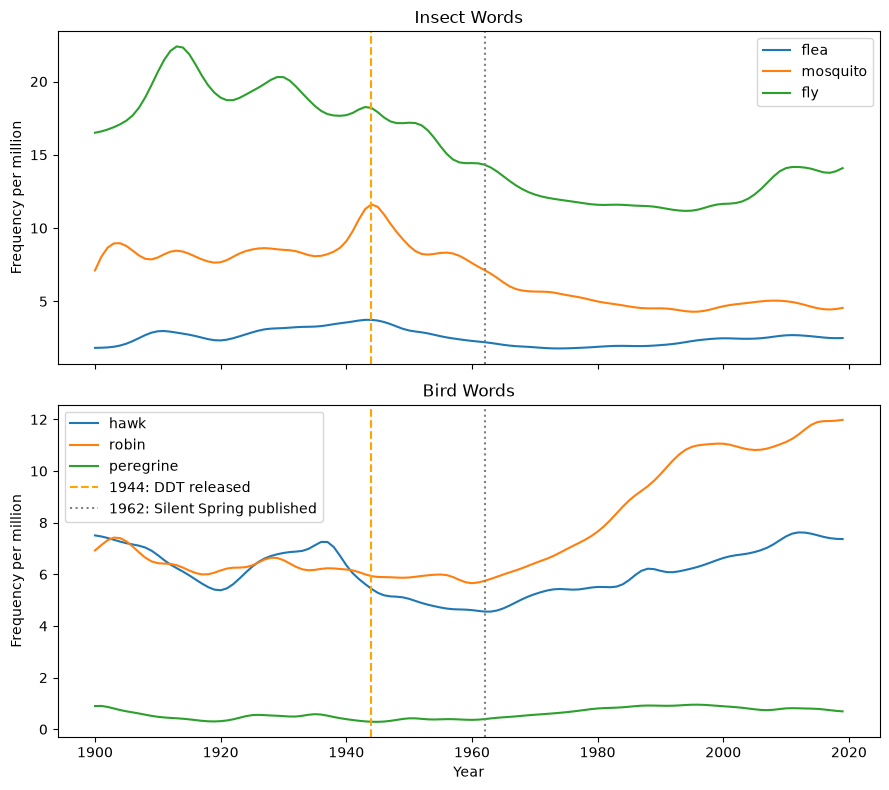

Chart Saved.


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for word in ['flea', 'mosquito', 'fly']:
    trend = df.query('word == @word')
    axes[0].plot(trend['year'], trend['frequency'], label=word)

axes[0].axvline(1944, color='orange', ls='--')
axes[0].axvline(1962, color='gray', ls=':')
axes[0].set_ylabel('Frequency per million')
axes[0].set_title('Insect Words')
axes[0].legend()

for word in ['hawk', 'robin', 'peregrine']:
    trend = df.query('word == @word')
    axes[1].plot(trend['year'], trend['frequency'], label=word)

axes[1].axvline(1944, color='orange', ls='--', label='1944: DDT released')
axes[1].axvline(1962, color='gray', ls=':', label='1962: Silent Spring published')
axes[1].set_ylabel('Frequency per million')
axes[1].set_xlabel('Year')
axes[1].set_title('Bird Words')
axes[1].legend()

plt.tight_layout()

plt.savefig('../images/plots/insect_vs_bird_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart Saved.")

## 7. Key Insights

- No clear shift in insect word frequency occurred immediately after **1944**. Most words continued their existing trends, suggesting that DDT's introduction did not instantly change public discussion of insects.

- Average sparrowhawk eggshell thickness declined by approximately **16.4%** after **1944**, providing evidence consistent with the view that DDT affected non-insect wildlife.

- All six bird words increased in average frequency after **1962**, likely reflecting increased public awareness following the publication of *Silent Spring* rather than improvements in bird populations.

- Word frequency measures **public attention**, not population size. The observed increase in bird-related words should therefore be interpreted as growing discussion, not ecological recovery.

- Taken together, the datasets suggest that the environmental effects associated with DDT emerged before widespread public recognition, highlighting the difference between ecological change and public awareness.